```markdown 
SCT211-0848/2018  
Jany Muong
```
# ICS 2405: Knowledge-Based Systems
## Traffic Accidents Classification Models:

> ##### CONTEXT:  
 > model architectures and evaluation techniques that are appropriate for classifiers(for the traffic accidents data).

1. Setup - Import Libraries and Configure Settings:
===================================================
This segment serves a place for imports/all the necessary libraries for data processing, visualization, classification models, and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# (mostly) preprocessing here:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.multiclass import OneVsRestClassifier

# metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    make_scorer
)

import itertools
from math import pi

# settings - not important
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# for reproducibility
np.random.seed(42)

2. Load the Data:
================================
This is meant to help me see what features to go for and what the model will likely pick - judging by the structure of the dataset: 

In [2]:
import os
# working directory
notebook_dir = '/home/mu-0/Computer-Science/CS41-Crunch-Time/ICS2405-KBS/EVAL2-Classification'
os.chdir(notebook_dir)
print(f"Working directory: {os.getcwd()}")

Working directory: /home/mu-0/Computer-Science/CS41-Crunch-Time/ICS2405-KBS/EVAL2-Classification


In [3]:
df = pd.read_excel('TRAFFIC-ACCIDENTS-DATA.xlsx')

print("Dataset Shape:", df.shape)
print(df.dtypes)

# 10 rows
pd.concat([df.head(5), df.tail(5)])

Dataset Shape: (78, 12)
date                     datetime64[ns]
accident_spot                    object
area                             object
county                           object
road_highway                     object
accident_cause                   object
victims                          object
total_dead                        int64
accident_spot_freq                int64
road_highway_freq                 int64
accident_cause_deaths           float64
risk_level                       object
dtype: object


,date,accident_spot,area,county,road_highway,accident_cause,victims,total_dead,accident_spot_freq,road_highway_freq,accident_cause_deaths,risk_level
0,2023-08-08,Sobea,Sobea,Nakuru,Nakuru-Eldoret Highway,Head on Collision,passengers,4,3,1,0.70,High
1,2023-08-07,Maai-Mahiu,Naivasha,Nakuru,Maai-Mahiu Naivasha Highway,vehicle and motorcycle collision,passengers,1,1,1,0.70,Medium
2,2023-07-25,Ntulele,Ntulele,Narok,Narok Mai Mahiu road,Head on Collision,drivers and passengers,4,2,5,0.70,High
3,2022-12-02,Suswa,Suswa,Narok,Narok Mai Mahiu road,Head on Collision,driver and passengers,3,2,5,0.70,Medium
4,2022-12-01,Mutira,Mutira,Kirinyaga,Kerugoya-Karatina Road,Run over,pedestrian,1,1,1,0.07,Low
73,2022-06-03,Losengeli,Sabatia,Vihiga,Nairobi Kakamega road,Bus lost control and rolled over,passengers,1,1,1,0.23,Low
74,2022-05-31,Isinya,Isinya,Kajiado,Namanga Road,Car rammed into a trailer,passengers,1,2,2,0.70,Medium
75,2022-05-30,Kinugi,Kinugi,Nakuru,Naivasha Nairobi Highway,Truck driver collided with an oncoming matatu,passengers,1,2,1,0.70,Medium
76,2022-02-28,Kinugi,Kinugi,Nakuru,Nakuru - Nairobi highway,Car rammed into a lorry,passengers,4,2,8,0.70,High
77,2023-08-08,Sobea,Sobea,Nakuru,Nakuru Eldoret Highway,matatu collided with a truck,passengers,2,3,6,0.70,Medium


In [4]:
# summary statistics
df.describe()

,date,total_dead,accident_spot_freq,road_highway_freq,accident_cause_deaths
count,78,78.000000,78.000000,78.000000,78.000000
mean,2022-12-27 18:46:09.230769152,4.807692,1.769231,3.692308,0.466410
min,2020-08-17 00:00:00,0.000000,1.000000,1.000000,0.070000
25%,2022-07-10 12:00:00,1.000000,1.000000,1.000000,0.230000
50%,2023-04-18 00:00:00,3.000000,1.000000,2.500000,0.700000
75%,2023-08-03 18:00:00,5.000000,2.000000,6.000000,0.700000
max,2023-09-27 00:00:00,52.000000,5.000000,8.000000,0.700000
std,NaN,6.877514,1.194392,2.600238,0.272521


3. Target Features
==================
From the output of the `risk_level` column this is a multiclass problemset.  
The best looking target feature is `risk_level` with **three classes**: **High**, **Medium**, and **Low**.

Risk Level Distribution:
risk_level
Medium    36
High      25
Low       17
Name: count, dtype: int64

Percentages:
risk_level
Medium    46.153846
High      32.051282
Low       21.794872
Name: proportion, dtype: float64


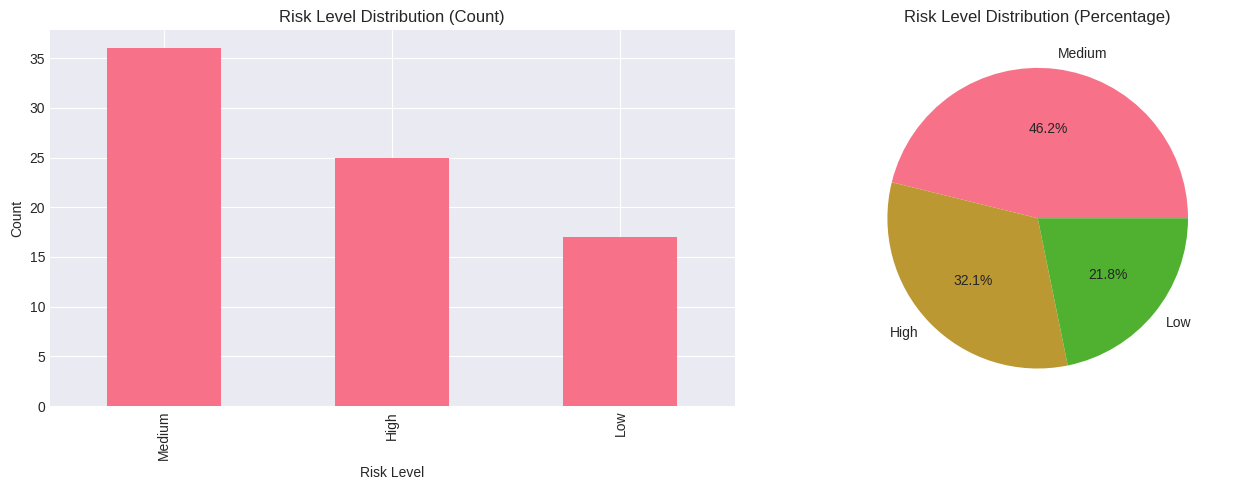

In [5]:
# target feature distribution
print("Risk Level Distribution:")
print(df['risk_level'].value_counts())
print("\nPercentages:")
print(df['risk_level'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['risk_level'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Risk Level Distribution (Count)')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

# pie chart
df['risk_level'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Risk Level Distribution (Percentage)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. A SMALL EDA: 
> this segment is still data exploration for human understanding(me and people)  
> the goal is to visualize relationships in the data.

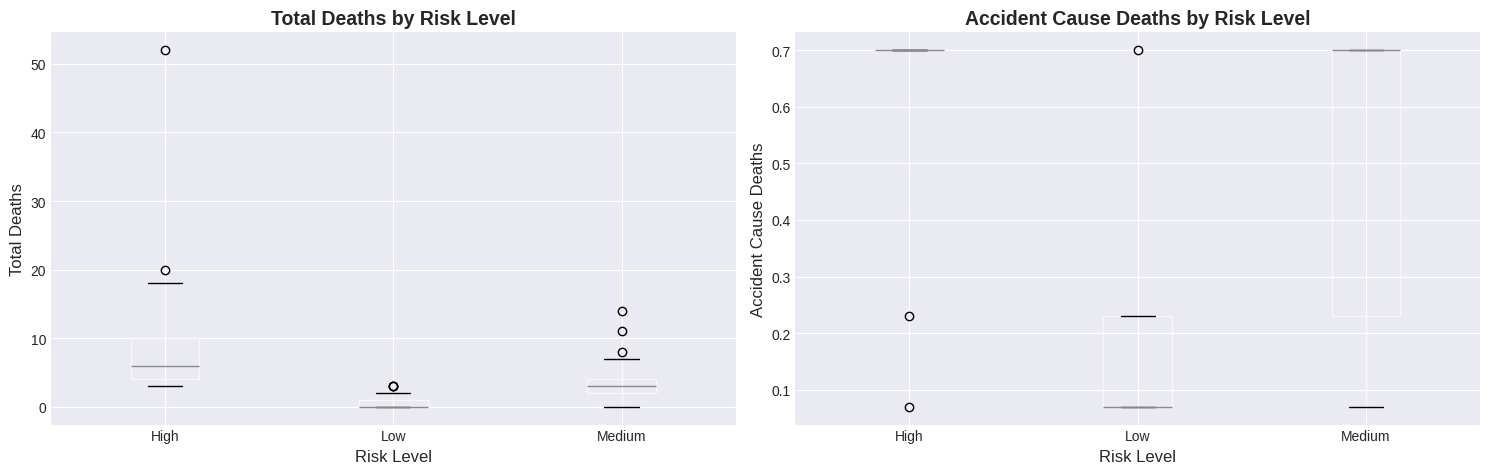

In [6]:
# r/ship between deaths and risk level
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# box plot for total deaths by risk level
df.boxplot(column='total_dead', by='risk_level', ax=axes[0])
axes[0].set_title('Total Deaths by Risk Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level', fontsize=12)
axes[0].set_ylabel('Total Deaths', fontsize=12)
plt.suptitle('')

# accident cause deaths by risk level
df.boxplot(column='accident_cause_deaths', by='risk_level', ax=axes[1])
axes[1].set_title('Accident Cause Deaths by Risk Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Level', fontsize=12)
axes[1].set_ylabel('Accident Cause Deaths', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

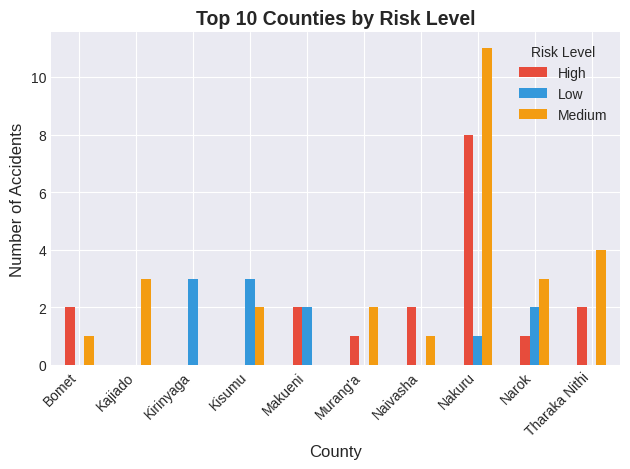

In [7]:
# top counties with accidents by risk level
plt.figure(figsize=(14, 6))
top_counties = df['county'].value_counts().head(10).index
df_top_counties = df[df['county'].isin(top_counties)]

county_risk = pd.crosstab(df_top_counties['county'], df_top_counties['risk_level'])
county_risk.plot(kind='bar', stacked=False, color=['#e74c3c', '#3498db', '#f39c12'])
plt.title('Top 10 Counties by Risk Level', fontsize=14, fontweight='bold')
plt.xlabel('County', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

5. Preprocessing:
=================
- encode categorical variables
- create temporal features from dates
- select relevant features
- standardize numerical features (important for K-NN)
- split data into training and testing sets

In [9]:
df_processed = df.copy()

# convert date to numerical features
df_processed['date'] = pd.to_datetime(df_processed['date'])
df_processed['year'] = df_processed['date'].dt.year
df_processed['month'] = df_processed['date'].dt.month
df_processed['day_of_week'] = df_processed['date'].dt.dayofweek

df_processed[['date', 'year', 'month', 'day_of_week']].head()

,date,year,month,day_of_week
0,2023-08-08,2023,8,1
1,2023-08-07,2023,8,0
2,2023-07-25,2023,7,1
3,2022-12-02,2022,12,4
4,2022-12-01,2022,12,3


In [10]:
categorical_features = ['county', 'victims', 'area', 'road_highway', 'accident_spot']

label_encoders = {}

# encode categorical features
for col in categorical_features:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} unique values")

county: 26 unique values
victims: 9 unique values
area: 59 unique values
road_highway: 39 unique values
accident_spot: 59 unique values


In [11]:
feature_columns = [
    'total_dead',
    'accident_spot_freq',
    'road_highway_freq',
    'accident_cause_deaths',
    'year',
    'month',
    'day_of_week',
    'county_encoded',
    'victims_encoded',
    'area_encoded',
    'road_highway_encoded',
    'accident_spot_encoded'
]

X = df_processed[feature_columns]
y = df_processed['risk_level']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures selected:")
print(feature_columns)

Features shape: (78, 12)
Target shape: (78,)

Features selected:
['total_dead', 'accident_spot_freq', 'road_highway_freq', 'accident_cause_deaths', 'year', 'month', 'day_of_week', 'county_encoded', 'victims_encoded', 'area_encoded', 'road_highway_encoded', 'accident_spot_encoded']


In [12]:
# split the data (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())

Training set size: (62, 12)
Testing set size: (16, 12)

Class distribution in training set:
risk_level
Medium    29
High      20
Low       13
Name: count, dtype: int64

Class distribution in testing set:
risk_level
Medium    7
High      5
Low       4
Name: count, dtype: int64


In [13]:
# standardize the features (important for K-NN and Naive Bayes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMean after scaling (approx ~0):")
print(pd.Series(X_train_scaled.mean(axis=0), index=feature_columns).head())
print("\nStd after scaling (approx ~1):")
print(pd.Series(X_train_scaled.std(axis=0), index=feature_columns).head())


Mean after scaling (approx ~0):
total_dead              -6.715059e-17
accident_spot_freq       4.297638e-17
road_highway_freq        1.002782e-16
accident_cause_deaths   -1.522080e-16
year                     4.409018e-14
dtype: float64

Std after scaling (approx ~1):
total_dead               1.0
accident_spot_freq       1.0
road_highway_freq        1.0
accident_cause_deaths    1.0
year                     1.0
dtype: float64


## 6. `Hand & Till M` Statistic for Multiclass `AUC`:

RATIONALE: this is a way/evaluator to handle AUC for multiclass problems by averaging pairwise AUCs.

In [14]:
def hand_and_till_M_statistic(test_tgt, test_probs, weighted=False, **kwargs):
    """
    Calculate Hand & Till M statistic for multiclass AUC.
    
    This computes AUC for each pair of classes and averages them.
    
    Parameters:
    -----------
    test_tgt : array-like
        True class labels
    test_probs : array-like, shape (n_samples, n_classes)
        Predicted probabilities for each class
    weighted : bool, default=False
        Whether to weight by proportion of examples
    **kwargs : dict
        Additional arguments (absorbs sklearn's extra parameters)
    
    Returns:
    --------
    M : float
        Hand & Till M statistic (0.5 to 1.0)
    """
    
    def auc_helper(truth, probs):
        """Helper to compute AUC for binary classification"""
        fpr, tpr, _ = roc_curve(truth, probs)
        return auc(fpr, tpr)
    
    # Convert to numpy array if pandas Series
    if hasattr(test_tgt, 'values'):
        test_tgt = test_tgt.values
    if hasattr(test_probs, 'values'):
        test_probs = test_probs.values
    
    # get unique classes and encode them
    classes = np.unique(test_tgt)
    n_classes = len(classes)
    
    # binarize labels
    indicator = label_binarize(test_tgt, classes=classes)
    
    avg_auc_sum = 0.0
    
    # iterate over all pairs of classes
    for i, j in itertools.combinations(range(n_classes), 2):
        # get mask for examples belonging to either class i or j
        ij_indicator = indicator[:, [i, j]].sum(axis=1, dtype=bool)
        
        # get subset for this pair
        ij_probs = test_probs[ij_indicator][:, [i, j]]
        ij_test_tgt = test_tgt[ij_indicator]
        
        # compute AUC in both directions
        auc_ij = auc_helper(ij_test_tgt == classes[i], ij_probs[:, 0])
        auc_ji = auc_helper(ij_test_tgt == classes[j], ij_probs[:, 1])
        
        # average for this pair
        avg_auc_ij = (auc_ij + auc_ji)
        
        if weighted:
            avg_auc_ij *= ij_indicator.sum() / len(test_tgt)
        
        avg_auc_sum += avg_auc_ij

    # final M statistic
    M = avg_auc_sum / (n_classes * (n_classes - 1))
    return M

7. Model Selection and Training:
================================

I have picked these classification models to go with:
- **K-Nearest Neighbors**: k=3 (3-NN), k=5 (5-NN), k=10 (10-NN)
- **Naive Bayes**: Gaussian Naive Bayes
- **Decision Tree**: max_depth=5 to prevent overfitting
- **Support Vector Machine**: Linear kernel

**NOTE**: different k values represent different model architectures for K-NN.

In [15]:
classifiers = {
    '3-NN': KNeighborsClassifier(n_neighbors=3),
    '5-NN': KNeighborsClassifier(n_neighbors=5),
    '10-NN': KNeighborsClassifier(n_neighbors=10),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

for name, clf in classifiers.items():
    print(f"  - {name}: {clf}")

  - 3-NN: KNeighborsClassifier(n_neighbors=3)
  - 5-NN: KNeighborsClassifier()
  - 10-NN: KNeighborsClassifier(n_neighbors=10)
  - Naive Bayes: GaussianNB()
  - Decision Tree: DecisionTreeClassifier(max_depth=5, random_state=42)
  - SVM: SVC(kernel='linear', probability=True, random_state=42)


In [16]:
trained_models = {}

print("Training Models: \n")
print("="*60)
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train)
    trained_models[name] = clf
    print(f"  ✓ {name} comeplete")

print("\n")
print(f"All {len(trained_models)} models trained!")
print("="*60)

Training Models: 

Training 3-NN...
  ✓ 3-NN comeplete
Training 5-NN...
  ✓ 5-NN comeplete
Training 10-NN...
  ✓ 10-NN comeplete
Training Naive Bayes...
  ✓ Naive Bayes comeplete
Training Decision Tree...
  ✓ Decision Tree comeplete
Training SVM...
  ✓ SVM comeplete


All 6 models trained!


8. Evaluation:
============

> we check each model against these **metrics**:
1. **accuracy**: overall correctness
2. **precision (macro)**: Positive predictive value averaged across classes
3. **recall (macro avergaging)**: True positive rate averaged across classes
4. **f1-score (macro)**: harmonic mean of precision and recall
5. **ROC-AUC (Hand & Till M)**: multiclass AUC using pairwise approach

In [17]:
# function to evaluate model with 5 metrics
def evaluate_model(model, X_test_data, y_test, model_name):
    """
    Evaluate a classification model using 5 metrics.
    """
    # make predictions
    y_pred = model.predict(X_test_data)
    y_probs = model.predict_proba(X_test_data)

    # calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # calculate Hand & Till M statistic (multiclass AUC)
    roc_auc = hand_and_till_M_statistic(y_test.values, y_probs)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'probabilities': y_probs
    }

print("Done")

Done


In [18]:
# all models
results = {}

print("Evaluating all models...\n")
print("="*80)

for model_name, model in trained_models.items():
    result = evaluate_model(model, X_test_scaled, y_test, model_name)
    results[model_name] = result

    # print results
    print(f"\n{model_name}")
    print("-" * 80)
    print(f"  1. Accuracy:       {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")
    print(f"  2. Precision:      {result['precision']:.4f}")
    print(f"  3. Recall:         {result['recall']:.4f}")
    print(f"  4. F1-Score:       {result['f1_score']:.4f}")
    print(f"  5. ROC-AUC (H&T M): {result['roc_auc']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(result['confusion_matrix'])

print("\n" + "="*80)
print("complete")
print("="*80)

Evaluating all models...


3-NN
--------------------------------------------------------------------------------
  1. Accuracy:       0.5625 (56.25%)
  2. Precision:      0.4074
  3. Recall:         0.5048
  4. F1-Score:       0.4508
  5. ROC-AUC (H&T M): 0.7899

  Confusion Matrix:
[[4 0 1]
 [1 0 3]
 [1 1 5]]

5-NN
--------------------------------------------------------------------------------
  1. Accuracy:       0.4375 (43.75%)
  2. Precision:      0.3056
  3. Recall:         0.3714
  4. F1-Score:       0.3236
  5. ROC-AUC (H&T M): 0.7923

  Confusion Matrix:
[[2 0 3]
 [0 0 4]
 [2 0 5]]

10-NN
--------------------------------------------------------------------------------
  1. Accuracy:       0.5625 (56.25%)
  2. Precision:      0.5000
  3. Recall:         0.4667
  4. F1-Score:       0.4127
  5. ROC-AUC (H&T M): 0.7940

  Confusion Matrix:
[[2 0 3]
 [0 0 4]
 [0 0 7]]

Naive Bayes
--------------------------------------------------------------------------------
  1. Accuracy:       

In [19]:
# create DataFrame
results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1_score'],
        'ROC-AUC': res['roc_auc']
    }
    for name, res in results.items()
])

# sort by F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n" + "="*90)
print("MODEL PERFORMANCE COMPARISON")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)


MODEL PERFORMANCE COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Naive Bayes    0.6875   0.708333 0.671429  0.685185 0.792857
Decision Tree    0.6250   0.623810 0.623810  0.623810 0.717857
          SVM    0.6250   0.681818 0.569048  0.583333 0.841667
         3-NN    0.5625   0.407407 0.504762  0.450758 0.789881
        10-NN    0.5625   0.500000 0.466667  0.412698 0.794048
         5-NN    0.4375   0.305556 0.371429  0.323587 0.792262


9. Visualization:
=====================
> for model performance

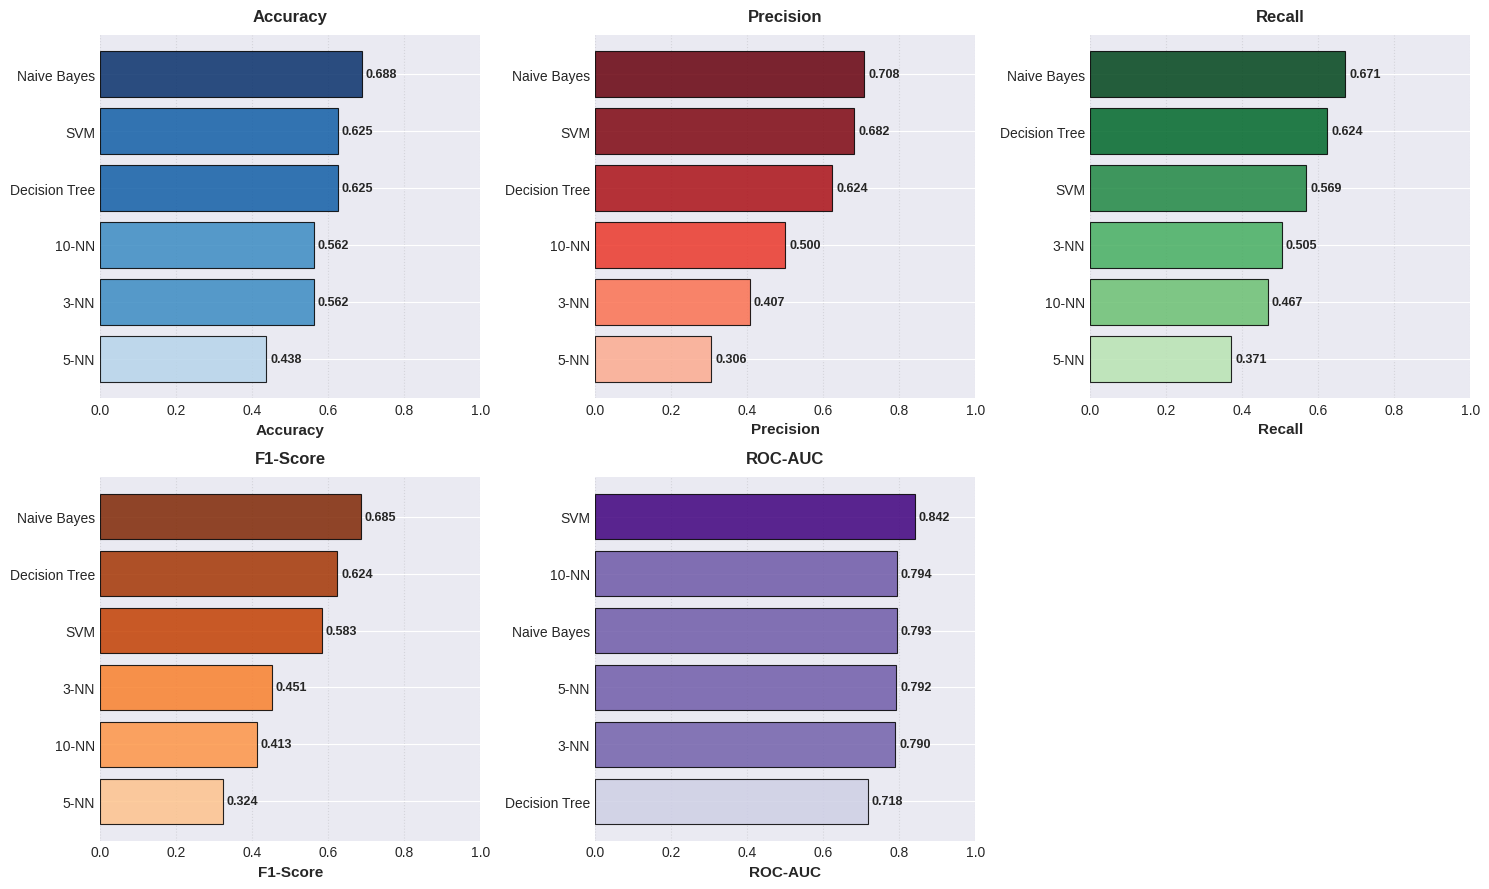

In [20]:
# compare models based on metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
base_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (metric, base_color) in enumerate(zip(metrics_to_plot, base_colors)):
    ax = axes[idx]
    sorted_df = results_df.sort_values(metric, ascending=True)

    values_normalized = (sorted_df[metric] - sorted_df[metric].min()) / (sorted_df[metric].max() - sorted_df[metric].min() + 0.001)

    if base_color == '#3498db':
        gradient_colors = [plt.cm.Blues(0.3 + 0.7 * val) for val in values_normalized]
    elif base_color == '#e74c3c':
        gradient_colors = [plt.cm.Reds(0.3 + 0.7 * val) for val in values_normalized]
    elif base_color == '#2ecc71':
        gradient_colors = [plt.cm.Greens(0.3 + 0.7 * val) for val in values_normalized]
    elif base_color == '#f39c12':
        gradient_colors = [plt.cm.Oranges(0.3 + 0.7 * val) for val in values_normalized]
    else:
        gradient_colors = [plt.cm.Purples(0.3 + 0.7 * val) for val in values_normalized]


    ax.barh(sorted_df['Model'], sorted_df[metric], color=gradient_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, v in enumerate(sorted_df[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.grid(axis='x', alpha=0.2, linestyle=':', color='gray')


fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

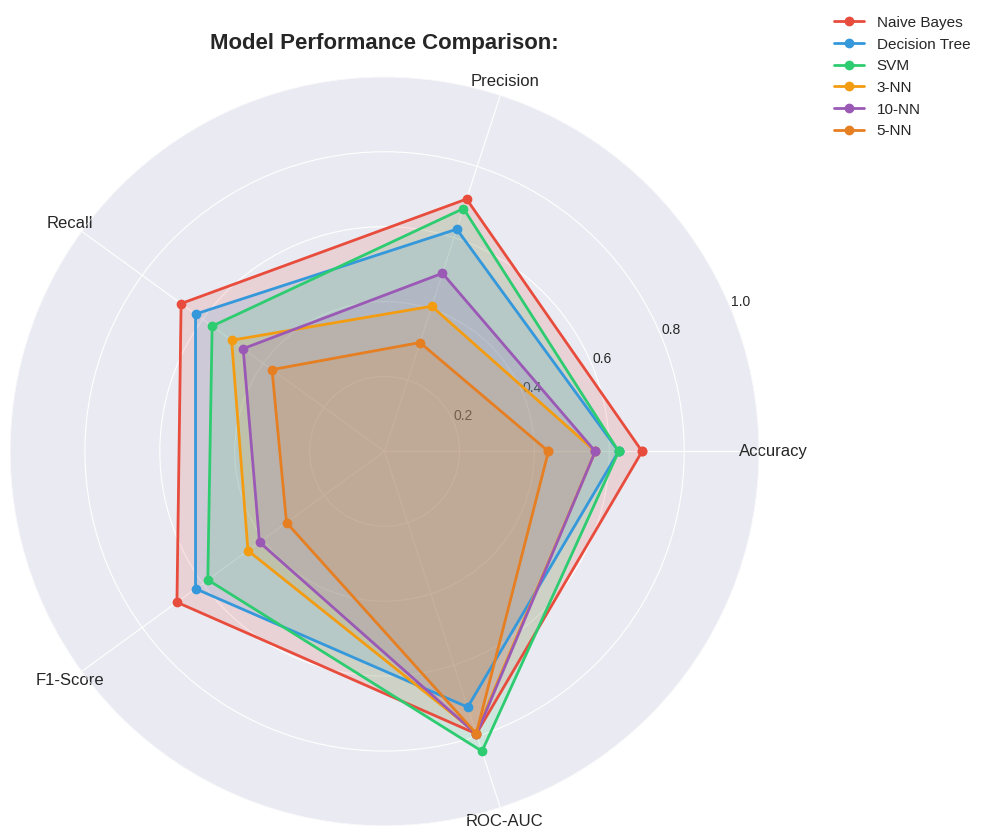

In [21]:
# radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categories)

# compute angles for each metric
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# initialize plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# plot each model;
colors_radar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22']
for idx, (_, row) in enumerate(results_df.iterrows()):
    values = row[categories].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

# customize plot
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison:', 
             size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

10. Confusion Matrix:
======================
> breakdown of predictions by class for each model.

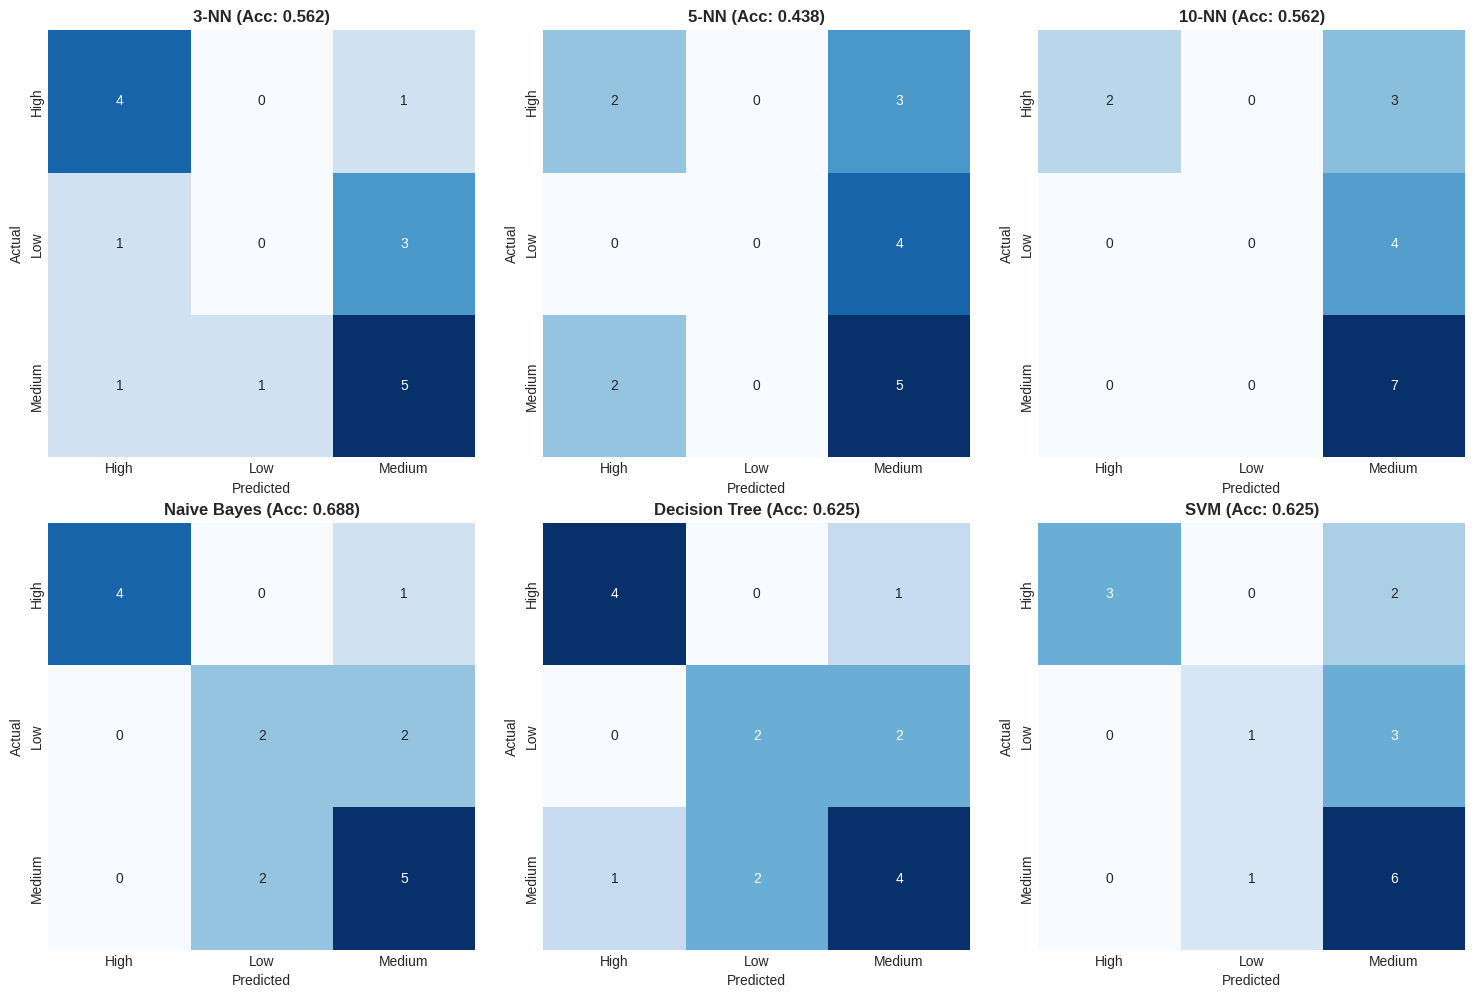

In [22]:
# confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# get class names from target
class_names = sorted(y_train.unique())

for idx, (model_name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    
    # plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names,
                yticklabels=class_names,
                cbar=False, square=True)

    acc = result['accuracy']
    axes[idx].set_title(f'{model_name} (Acc: {acc:.3f})', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

11. `ROC Curves` for Multiclass Classification:
===============================================

Using `One-vs-Rest (OvR)` to visualize `ROC` curves for each class.

In [23]:
# binarize the target for multiclass ROC
classes = sorted(y_train.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

print(f"Classes: {classes}")

Classes: ['High', 'Low', 'Medium']


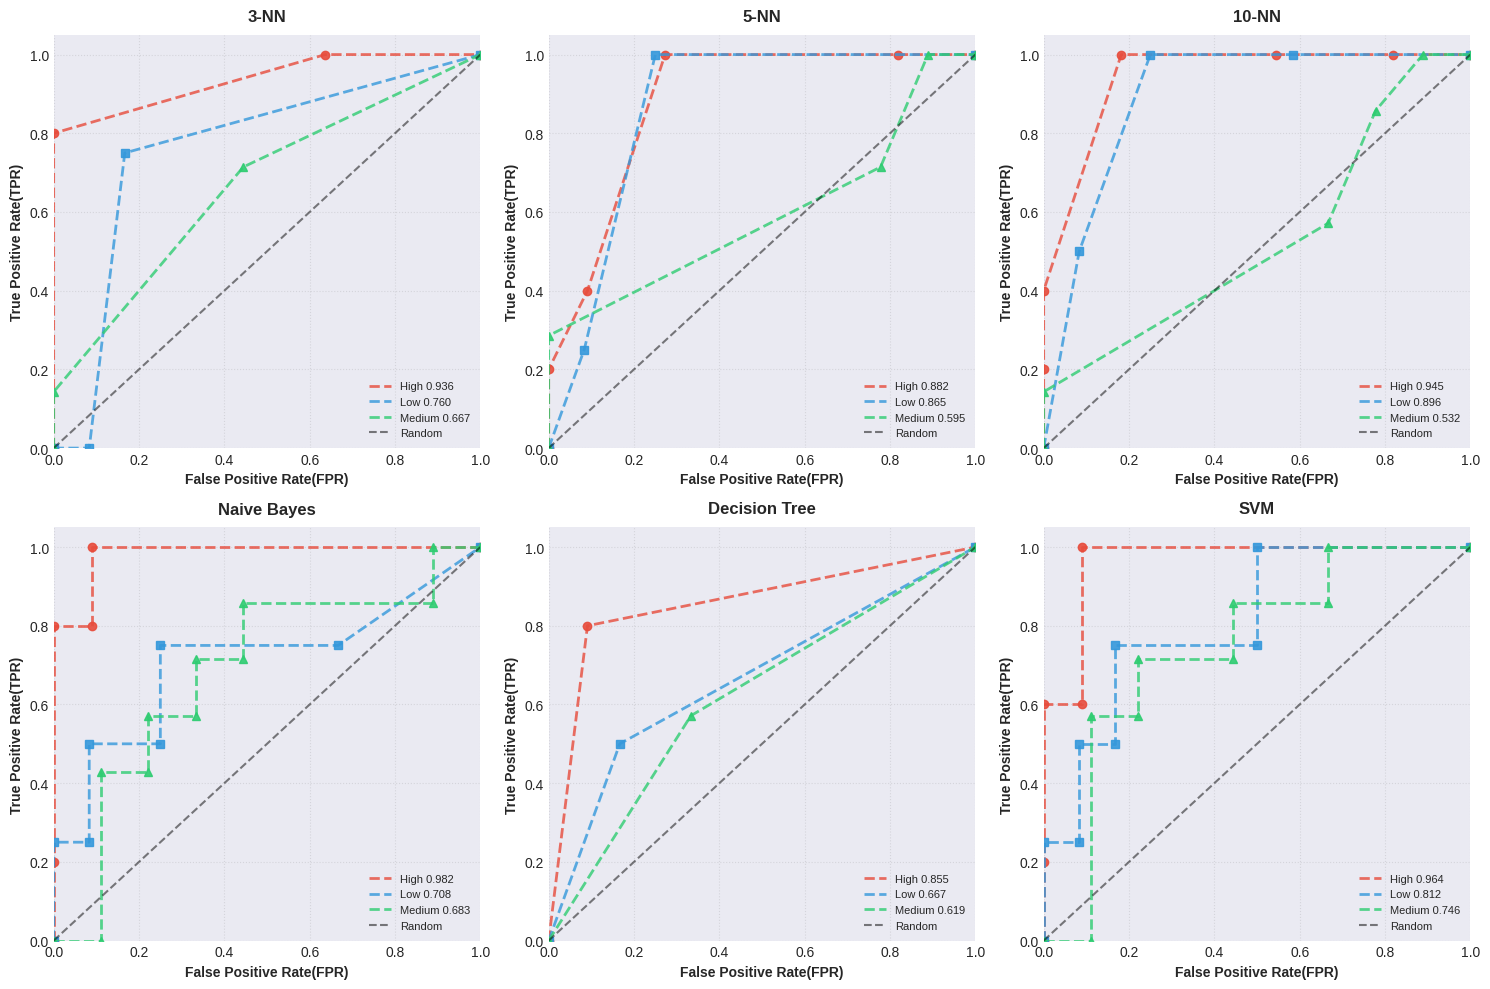

In [24]:
# ROC curves for each model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()


colors_roc = ['#e74c3c', '#3498db', '#2ecc71']
markers = ['o', 's', '^']  # circle, square, triangle


for idx, (model_name, result) in enumerate(results.items()):
    ax = axes[idx]
    y_probs = result['probabilities']

    # plot ROC curve for each class vs rest with dashed lines and markers
    for i, (class_name, color, marker) in enumerate(zip(classes, colors_roc, markers)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        # sample points for better visualization
        step = max(1, len(fpr) // 10)
        ax.plot(fpr, tpr, color=color, linestyle='--', linewidth=2, alpha=0.8,
                label=f'{class_name} {roc_auc:.3f}')
        ax.plot(fpr[::step], tpr[::step], marker=marker, color=color, markersize=6, linestyle='', alpha=0.9)

    # plot diagonal (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random')

    # customize plot
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate(FPR)', fontsize=10, fontweight='bold')
    ax.set_ylabel('True Positive Rate(TPR)', fontsize=10, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)

    ax.legend(loc='lower right', fontsize=8, framealpha=0.95)
    ax.grid(alpha=0.2, linestyle=':', color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

## 12. 10-Fold Cross-Validation:
> a `k-fold` `cv`:

A **10-fold** cross-validation helps me get more robust performance estimates out of my models.

In [25]:

# htm_scorer = make_scorer(hand_and_till_M_statistic, needs_proba=True)

# scorers = {
#     'Accuracy': 'accuracy',
#     'Precision': 'precision_macro',    # built-in scorer
#     'Recall': 'recall_macro',          # built-in scorer
#     'H&T M (AUC)': htm_scorer
# }

# wrapper scorer that properly handles probabilities;
def htm_scorer_wrapper(estimator, X, y):
    """wrapper that gets probabilities from estimator during CV"""
    y_probs = estimator.predict_proba(X)
    return hand_and_till_M_statistic(y, y_probs)

# pass the wrapper directly
# coz sklearn accepts scorers with signature (estimator, X, y))
scorers = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'H&T M (AUC)': htm_scorer_wrapper
}

In [26]:
# 10-fold cross-validation for each model and and metric
import warnings
from sklearn.exceptions import UndefinedMetricWarning

cv_results = {}

print("10-fold cross-validation: \n")
print("="*80)

# suppress precision warnings for small folds
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

    for model_name, model in classifiers.items():
        print(f"\n{model_name}:")
        cv_results[model_name] = {}
        
        for metric_name, scorer in scorers.items():
            scores = cross_val_score(model, X_train_scaled, y_train,
                                     scoring=scorer, cv=10)

            cv_results[model_name][metric_name] = scores
            print(f"  {metric_name:15s}: {scores.mean():.4f} (±{scores.std():.4f})")

print("\n" + "="*80)

10-fold cross-validation: 


3-NN:
  Accuracy       : 0.4190 (±0.1935)
  Precision      : 0.3550 (±0.2342)
  Recall         : 0.4056 (±0.2034)
  H&T M (AUC)    : 0.6458 (±0.2001)

5-NN:
  Accuracy       : 0.5643 (±0.1776)
  Precision      : 0.5856 (±0.2133)
  Recall         : 0.6167 (±0.1867)
  H&T M (AUC)    : 0.7049 (±0.1867)

10-NN:
  Accuracy       : 0.5690 (±0.2049)
  Precision      : 0.5400 (±0.3120)
  Recall         : 0.5556 (±0.2370)
  H&T M (AUC)    : 0.7764 (±0.1267)

Naive Bayes:
  Accuracy       : 0.6571 (±0.1926)
  Precision      : 0.6778 (±0.2364)
  Recall         : 0.7000 (±0.1575)
  H&T M (AUC)    : 0.8569 (±0.0824)

Decision Tree:
  Accuracy       : 0.8381 (±0.1494)
  Precision      : 0.8556 (±0.1908)
  Recall         : 0.8556 (±0.1388)
  H&T M (AUC)    : 0.8917 (±0.1041)

SVM:
  Accuracy       : 0.6762 (±0.2449)
  Precision      : 0.6944 (±0.2588)
  Recall         : 0.6889 (±0.2096)
  H&T M (AUC)    : 0.8681 (±0.0936)



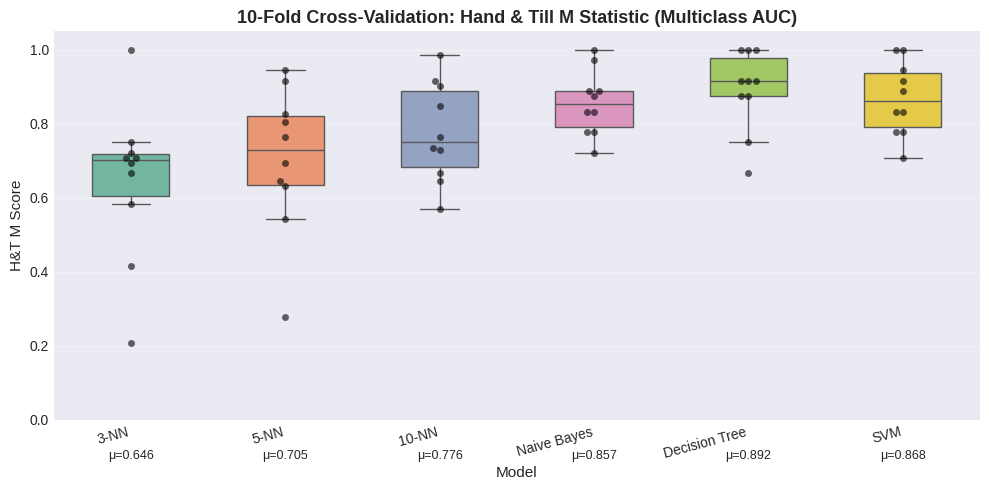

In [27]:
# visualize Hand & Till M (ROC-AUC) scores 
# with a swarmplot

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# collect H&T M scores for each model
htm_data = []

for model_name in classifiers.keys():
    htm_scores = cv_results[model_name]['H&T M (AUC)']
    # Filter out NaN values
    for score in htm_scores:
        if not np.isnan(score):
            htm_data.append({'Model': model_name, 'H&T M Score': score})

# create DataFrame
htm_df = pd.DataFrame(htm_data)

# plot (only) if we have data
if len(htm_df) > 0:
    # create swarmplot with boxplot overlay
    sns.boxplot(x='Model', y='H&T M Score', data=htm_df, ax=ax, 
                hue='Model', palette='Set2', showfliers=False, width=0.5, legend=False)
    sns.swarmplot(x='Model', y='H&T M Score', data=htm_df, ax=ax, 
                  color='black', alpha=0.6, size=5)

    ax.set_title('10-Fold Cross-Validation: Hand & Till M Statistic (Multiclass AUC)', 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('H&T M Score', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)

    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])

    # add mean values as text
    for i, model_name in enumerate(classifiers.keys()):
        scores = cv_results[model_name]['H&T M (AUC)']
        # Filter NaN and compute mean
        valid_scores = scores[~np.isnan(scores)]
        if len(valid_scores) > 0:
            mean_score = valid_scores.mean()
            ax.text(i, -0.08, f'μ={mean_score:.3f}', ha='center', va='top', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No valid H&T M scores computed', 
            ha='center', va='center', transform=ax.transAxes)


plt.tight_layout()
plt.show()

13. Classification Report:
==========================
Per-class performance/metrics for the best model.

In [28]:
# best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_result = results[best_model_name]

y_pred_best = best_result['predictions']

# classification report
print("="*80)

print(f"BEST MODEL: {best_model_name}")
print("="*80)

print("\nClassification Report (Per-Class Metrics):")
print("-"*80)
print(classification_report(y_test, y_pred_best, target_names=classes))
print("="*80)

BEST MODEL: Naive Bayes

Classification Report (Per-Class Metrics):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        High       1.00      0.80      0.89         5
         Low       0.50      0.50      0.50         4
      Medium       0.62      0.71      0.67         7

    accuracy                           0.69        16
   macro avg       0.71      0.67      0.69        16
weighted avg       0.71      0.69      0.69        16



---------------------------
14. Ensemble Methods Models:
============================

This is a segment for advanced ensemble techniques:
- **Random Forest**: decision trees with bagging
- **XGBoost**: gradient boosting with regularization

NOTe: high performance - I expected them to better than the ones above since there is regularization in the mix.

In [29]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


# from xgboost import XGBClassifier  #  - requires CUDA/GPU dependencies( I dotn have an nvidia GPU)
# advanced classifiers
advanced_classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    # 'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
    #                         random_state=42, eval_metric='mlogloss')
}

# train + evaluate RandomForestClassifier
advanced_results = {}

print("Random Forest Model:\n")
print("="*80)


for name, clf in advanced_classifiers.items():
    print(f"\n{name}:")

    # train
    clf.fit(X_train_scaled, y_train)

    # evaluate
    result = evaluate_model(clf, X_test_scaled, y_test, name)
    advanced_results[name] = result

    # 10-fold CV with zero_division parameter to suppress warnings
    print("  Cross-Validation Scores:")
    for metric_name, scorer in scorers.items():
        scores = cross_val_score(clf, X_train_scaled, y_train, 
                                scoring=scorer, cv=10)
        print(f"    {metric_name:15s}: {scores.mean():.4f} (±{scores.std():.4f})")


    print(f"\n  Test Set Performance:")
    print(f"    Accuracy:  {result['accuracy']:.4f}")
    print(f"    Precision: {result['precision']:.4f}")
    print(f"    Recall:    {result['recall']:.4f}")
    print(f"    F1-Score:  {result['f1_score']:.4f}")
    print(f"    ROC-AUC:   {result['roc_auc']:.4f}")

print("\n" + "="*80)

Random Forest Model:


Random Forest:
  Cross-Validation Scores:
    Accuracy       : 0.7476 (±0.1518)
    Precision      : 0.7144 (±0.2320)
    Recall         : 0.7389 (±0.1512)
    H&T M (AUC)    : 0.9167 (±0.0556)

  Test Set Performance:
    Accuracy:  0.5625
    Precision: 0.5556
    Recall:    0.5405
    F1-Score:  0.5313
    ROC-AUC:   0.8762



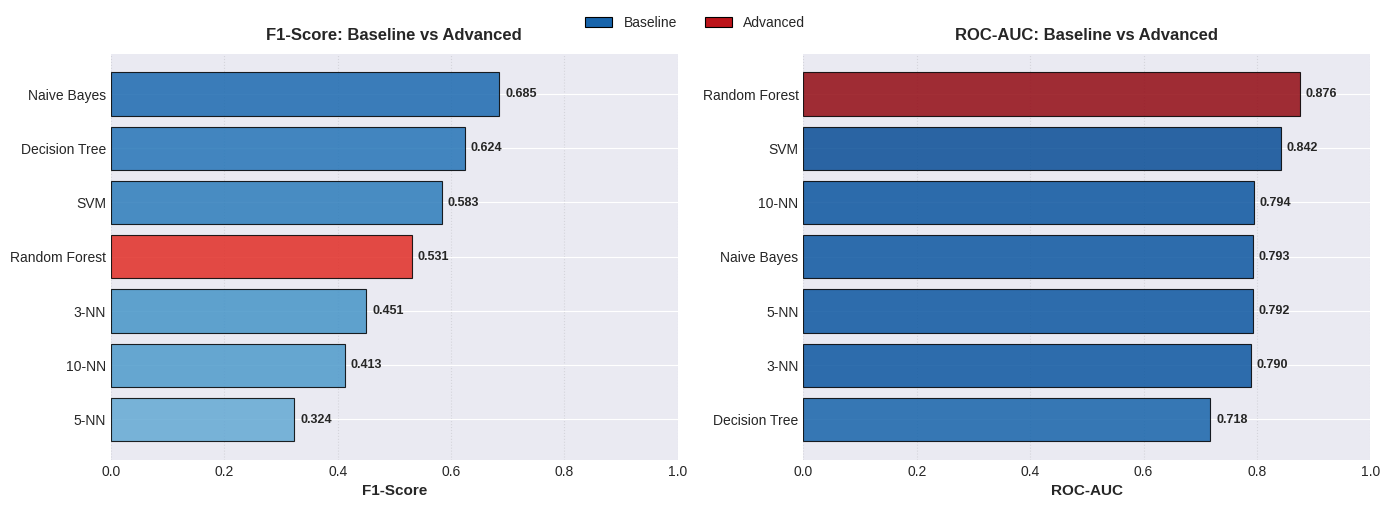

In [30]:
# compare models with baseline models
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# combine all results
all_models_comparison = []

# baseline models
for name, res in results.items():
    all_models_comparison.append({
        'Model': name,
        'Type': 'Baseline',
        'F1-Score': res['f1_score'],
        'ROC-AUC': res['roc_auc']
    })

# advanced models
for name, res in advanced_results.items():
    all_models_comparison.append({
        'Model': name,
        'Type': 'Advanced',
        'F1-Score': res['f1_score'],
        'ROC-AUC': res['roc_auc']
    })

comparison_df = pd.DataFrame(all_models_comparison)

# plot for F1-Score
ax1 = axes[0]
sorted_df = comparison_df.sort_values('F1-Score', ascending=True)
colors = []
for t, val in zip(sorted_df['Type'], sorted_df['F1-Score']):
    if t == 'Baseline':
        intensity = 0.3 + 0.7 * val
        colors.append(plt.cm.Blues(intensity))
    else:
        intensity = 0.3 + 0.7 * val
        colors.append(plt.cm.Reds(intensity))

ax1.barh(sorted_df['Model'], sorted_df['F1-Score'], color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax1.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax1.set_title('F1-Score: Baseline vs Advanced', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlim(0, 1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.2, linestyle=':', color='gray')

for i, v in enumerate(sorted_df['F1-Score']):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# plot ROC-AUC
ax2 = axes[1]
sorted_df = comparison_df.sort_values('ROC-AUC', ascending=True)
colors = []
for t, val in zip(sorted_df['Type'], sorted_df['ROC-AUC']):
    if t == 'Baseline':
        intensity = 0.3 + 0.7 * val
        colors.append(plt.cm.Blues(intensity))
    else:
        intensity = 0.3 + 0.7 * val
        colors.append(plt.cm.Reds(intensity))

ax2.barh(sorted_df['Model'], sorted_df['ROC-AUC'], color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('ROC-AUC', fontsize=11, fontweight='bold')
ax2.set_title('ROC-AUC: Baseline vs Advanced', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlim(0, 1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.2, linestyle=':', color='gray')


for i, v in enumerate(sorted_df['ROC-AUC']):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# legend
legend_elements = [
    Patch(facecolor=plt.cm.Blues(0.8), edgecolor='black', label='Baseline', linewidth=0.8),
    Patch(facecolor=plt.cm.Reds(0.8), edgecolor='black', label='Advanced', linewidth=0.8)
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), framealpha=0.95, edgecolor='black')


plt.tight_layout()
plt.show()

15. Conclusions:
================

Summary of all models with their performance across all 5 metrics.

In [31]:
# summary
print("\n" + "="*100)
print("\n5 EVALUATION METRICS USED:")
print("  1. Accuracy:       Proportion of correct predictions")
print("  2. Precision:      Ratio of true positives to predicted positives (macro avg)")
print("  3. Recall:         Ratio of true positives to actual positives (macro avg)")
print("  4. F1-Score:       Harmonic mean of precision and recall (macro avg)")
print("  5. ROC-AUC:        Hand & Till M statistic for multiclass AUC")

print("\n" + "="*100)
print("\nPERFORMANCE RANKING (by F1-Score):")
print("-"*100)
for idx, row in results_df.iterrows():
    print(f"  {idx+1}. {row['Model']:<15} "
          f"F1={row['F1-Score']:.4f}  "
          f"Acc={row['Accuracy']:.4f}  "
          f"Prec={row['Precision']:.4f}  "
          f"Rec={row['Recall']:.4f}  "
          f"AUC={row['ROC-AUC']:.4f}")

print("-"*100)
print(f"\nRECOMMENDED MODEL: {best_model_name}")
print(f"  Reason: Highest F1-Score of {results_df.iloc[0]['F1-Score']:.4f}")
print(f"  This model provides the best balance between precision and recall.")
print("="*100)



5 EVALUATION METRICS USED:
  1. Accuracy:       Proportion of correct predictions
  2. Precision:      Ratio of true positives to predicted positives (macro avg)
  3. Recall:         Ratio of true positives to actual positives (macro avg)
  4. F1-Score:       Harmonic mean of precision and recall (macro avg)
  5. ROC-AUC:        Hand & Till M statistic for multiclass AUC


PERFORMANCE RANKING (by F1-Score):
----------------------------------------------------------------------------------------------------
  1. Naive Bayes     F1=0.6852  Acc=0.6875  Prec=0.7083  Rec=0.6714  AUC=0.7929
  2. Decision Tree   F1=0.6238  Acc=0.6250  Prec=0.6238  Rec=0.6238  AUC=0.7179
  3. SVM             F1=0.5833  Acc=0.6250  Prec=0.6818  Rec=0.5690  AUC=0.8417
  4. 3-NN            F1=0.4508  Acc=0.5625  Prec=0.4074  Rec=0.5048  AUC=0.7899
  5. 10-NN           F1=0.4127  Acc=0.5625  Prec=0.5000  Rec=0.4667  AUC=0.7940
  6. 5-NN            F1=0.3236  Acc=0.4375  Prec=0.3056  Rec=0.3714  AUC=0.7923
------

-------------
## 14. Conclusion:

### What Was Done:

#### 1. **Dataset Preparation**
   - Loaded **Road Traffic Accidents dataset** with 78 accident records
   - **12 features** including temporal (date), location (county, area), and accident characteristics (victims, road type, accident spot)
   - **Target variable**: `risk_level` with 3 classes (High, Medium, Low)
   - **No missing values** found in the dataset
   - **Class distribution**: Medium (46%), High (32%), Low (22%) - slight imbalance

#### 2. **Data Preprocessing**
   - **Feature Engineering**:
     - Extracted temporal features: year, month, day_of_week from accident dates
     - Label-encoded 5 categorical features (county, victims, area, road_type, accident_spot)
   - **Standardization**: Applied StandardScaler to all features (critical for distance-based models like K-NN and SVM)
   - **Data Split**: 80-20 train-test split with stratification to maintain class proportions

#### 3. **Classification Models**
   **6 different classification models**:

   - **K-Nearest Neighbors (3 variants)**:
     - **3-NN**: k=3 neighbors - most sensitive to local patterns, captures fine details
     - **5-NN**: k=5 neighbors - balanced approach between sensitivity and generalization
     - **10-NN**: k=10 neighbors - smoother decision boundaries, more robust to noise
     - *Why K-NN?* Non-parametric, instance-based learning, effective for small datasets

   - **Naive Bayes** (GaussianNB):
     - Probabilistic classifier assuming Gaussian distribution
     - *Why Naive Bayes?* Fast training, works well with small datasets, provides probability estimates

   - **Decision Tree** (max_depth=5):
     - Tree-based model with limited depth to prevent overfitting
     - *Why Decision Tree?* Interpretable rules, handles non-linear relationships, no scaling required
   
   - **Support Vector Machine** (Linear kernel):
     - Linear SVM with probability estimates enabled
     - *Why SVM?* Effective in high-dimensional spaces, finds optimal decision boundaries

#### 4. **Evaluation Metrics**
   Used **5 comprehensive metrics** for model assessment:
   
   - **Accuracy**: Overall prediction correctness across all classes
   - **Precision (macro)**: Quality of positive predictions (minimizes false positives)
   - **Recall (macro)**: Coverage of actual positives (minimizes false negatives)
   - **F1-Score (macro)**: Harmonic mean of precision and recall (balanced metric)
   - **ROC-AUC (Hand & Till M statistic)**: Proper multiclass AUC computed via pairwise class comparisons

#### 5. **Validation Strategy**
   - **10-fold cross-validation** on training set for robust performance estimates
   - **Confusion matrices** to analyze per-class prediction patterns
   - **ROC curves** (One-vs-Rest) for each class discrimination ability

---

WRAPS: Comments
===============

**Cross-Validation Results (10-fold CV on training set):**
- **Decision Tree** achieved highest performance: 83.8% accuracy, 89.2% AUC
- **SVM** and **Naive Bayes** showed strong performance: 86.8% and 85.7% AUC respectively
- **K-NN performance improved with k**: 3-NN (64.6% AUC) < 5-NN (70.5% AUC) < 10-NN (77.6% AUC)
- **Decision Tree** demonstrated best balance across all metrics with consistent performance

**Model Characteristics:**
- **Decision Tree** excels at capturing complex feature
- **Naive Bayes** provides probabilistic predictions and fast inference
- **SVM** effectively separates classes in scaled feature space
- **K-NN variants** show sensitivity to hyperparameter selection (k value impact)

----------------
```markdown
SCT211-0848/2018  
Jany Muong
```
-----------------

END
====